In [1]:
# Hospital Healthcare Analytics
# 01 - Data Quality Audit

print("=" * 80)
print("HOSPITAL HEALTHCARE ANALYTICS - DATA QUALITY AUDIT")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries loaded successfully.")


HOSPITAL HEALTHCARE ANALYTICS - DATA QUALITY AUDIT
Libraries loaded successfully.


In [22]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record-data-analyst-cleaned"
)

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("Raw data exists:", RAW_DATA.exists())

Project root: C:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record-data-analyst-cleaned
Raw data: C:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record-data-analyst-cleaned\data\raw
Raw data exists: True


In [3]:
patients = pd.read_csv(RAW_DATA / "patients.csv")
encounters = pd.read_csv(RAW_DATA / "encounters.csv")
procedures = pd.read_csv(RAW_DATA / "procedures.csv")
payers = pd.read_csv(RAW_DATA / "payers.csv")
organizations = pd.read_csv(RAW_DATA / "organizations.csv")
data_dictionary = pd.read_csv(RAW_DATA / "data_dictionary.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
datasets = {
    "Patients": patients,
    "Encounters": encounters,
    "Procedures": procedures,
    "Payers": payers,
    "Organizations": organizations,
    "Data Dictionary": data_dictionary
}

for name, df in datasets.items():
    print(f"{name:20} {df.shape[0]:>8,} rows | {df.shape[1]:>3} columns")

Patients                  974 rows |  20 columns
Encounters             27,891 rows |  14 columns
Procedures             47,701 rows |   9 columns
Payers                     10 rows |   7 columns
Organizations               1 rows |   8 columns
Data Dictionary            65 rows |   3 columns


In [5]:
duplicate_results = []

for name, df in datasets.items():
    duplicate_results.append({
        "Dataset": name,
        "Duplicate Rows": df.duplicated().sum()
    })

duplicates = pd.DataFrame(duplicate_results)
duplicates

,Dataset,Duplicate Rows
0,Patients,0
1,Encounters,0
2,Procedures,0
3,Payers,0
4,Organizations,0
5,Data Dictionary,0


In [6]:
missing_results = []

for name, df in datasets.items():
    for column in df.columns:
        missing = df[column].isna().sum()

        if missing > 0:
            missing_results.append({
                "Dataset": name,
                "Column": column,
                "Missing": missing,
                "Percentage": round(
                    missing / len(df) * 100, 2
                )
            })

missing_df = pd.DataFrame(missing_results)

missing_df.sort_values(
    "Percentage",
    ascending=False
)

,Dataset,Column,Missing,Percentage
1,Patients,SUFFIX,953,97.84
0,Patients,DEATHDATE,820,84.19
7,Procedures,REASONCODE,36945,77.45
8,Procedures,REASONDESCRIPTION,36945,77.45
6,Encounters,REASONDESCRIPTION,19541,70.06
5,Encounters,REASONCODE,19541,70.06
2,Patients,MAIDEN,588,60.37
4,Patients,ZIP,142,14.58
11,Payers,STATE_HEADQUARTERED,1,10.00
9,Payers,ADDRESS,1,10.00


C:\Users\Olayinka\AppData\Local\Temp\ipykernel_19948\3703639819.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record-data-analyst-cleaned\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


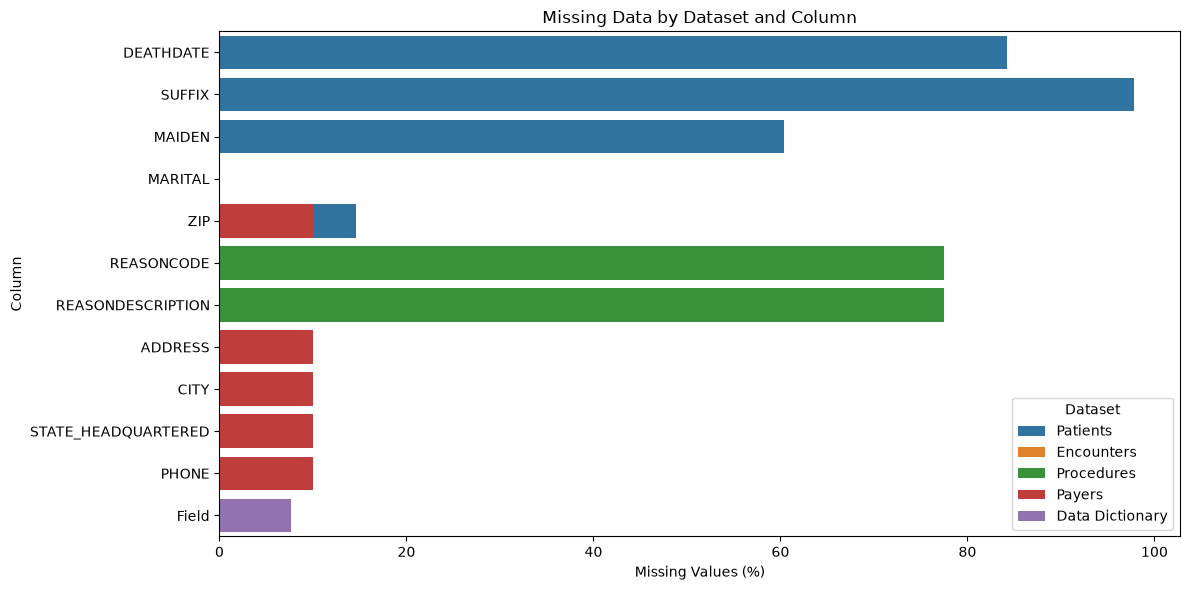

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_df,
    x="Percentage",
    y="Column",
    hue="Dataset",
    dodge=False
)

plt.title("Missing Data by Dataset and Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "images" / "01_data_quality_audit" / "missing_dataset.png")

plt.show()

In [8]:
patient_ids = set(patients["Id"])
payer_ids = set(payers["Id"])
organization_ids = set(organizations["Id"])
encounter_ids = set(encounters["Id"])

orphan_encounters = (~encounters["PATIENT"].isin(patient_ids)).sum()
orphan_payers = (~encounters["PAYER"].isin(payer_ids)).sum()
orphan_organizations = (~encounters["ORGANIZATION"].isin(organization_ids)).sum()

orphan_procedures = (~procedures["ENCOUNTER"].isin(encounter_ids)).sum()

print("Orphan encounters - patients:", orphan_encounters)
print("Orphan encounters - payers:", orphan_payers)
print("Orphan encounters - organizations:", orphan_organizations)
print("Orphan procedures - encounters:", orphan_procedures)

Orphan encounters - patients: 0
Orphan encounters - payers: 0
Orphan encounters - organizations: 0
Orphan procedures - encounters: 0


Check encounter relationships

In [9]:
patient_ids = set(patients["Id"])
payer_ids = set(payers["Id"])
organization_ids = set(organizations["Id"])
encounter_ids = set(encounters["Id"])

orphan_encounters = (~encounters["PATIENT"].isin(patient_ids)).sum()
orphan_payers = (~encounters["PAYER"].isin(payer_ids)).sum()
orphan_organizations = (~encounters["ORGANIZATION"].isin(organization_ids)).sum()

orphan_procedures = (~procedures["ENCOUNTER"].isin(encounter_ids)).sum()

print("Orphan encounters - patients:", orphan_encounters)
print("Orphan encounters - payers:", orphan_payers)
print("Orphan encounters - organizations:", orphan_organizations)
print("Orphan procedures - encounters:", orphan_procedures)

Orphan encounters - patients: 0
Orphan encounters - payers: 0
Orphan encounters - organizations: 0
Orphan procedures - encounters: 0


Validate dates

In [10]:
encounters["START"] = pd.to_datetime(encounters["START"], errors="coerce")
encounters["STOP"] = pd.to_datetime(encounters["STOP"], errors="coerce")

procedures["START"] = pd.to_datetime(procedures["START"], errors="coerce")
procedures["STOP"] = pd.to_datetime(procedures["STOP"], errors="coerce")

invalid_encounter_dates = (
    encounters["START"].isna() |
    encounters["STOP"].isna() |
    (encounters["STOP"] < encounters["START"])
).sum()

invalid_procedure_dates = (
    procedures["START"].isna() |
    procedures["STOP"].isna() |
    (procedures["STOP"] < procedures["START"])
).sum()

print("Invalid encounter dates:", invalid_encounter_dates)
print("Invalid procedure dates:", invalid_procedure_dates)

Invalid encounter dates: 0
Invalid procedure dates: 0


In [11]:
# After loading patients, encounters, procedures, etc.
print("Patients data info:")
print(patients.info())
print(patients.describe(include='all'))

print("\nEncounters data info:")
print(encounters.info())
print(encounters.describe(include='all'))

print("\nProcedures data info:")
print(procedures.info())
print(procedures.describe(include='all'))


Patients data info:
<class 'pandas.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    str    
 1   BIRTHDATE   974 non-null    str    
 2   DEATHDATE   154 non-null    str    
 3   PREFIX      974 non-null    str    
 4   FIRST       974 non-null    str    
 5   LAST        974 non-null    str    
 6   SUFFIX      21 non-null     str    
 7   MAIDEN      386 non-null    str    
 8   MARITAL     973 non-null    str    
 9   RACE        974 non-null    str    
 10  ETHNICITY   974 non-null    str    
 11  GENDER      974 non-null    str    
 12  BIRTHPLACE  974 non-null    str    
 13  ADDRESS     974 non-null    str    
 14  CITY        974 non-null    str    
 15  STATE       974 non-null    str    
 16  COUNTY      974 non-null    str    
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON         974 non-

In [12]:
# Show data dictionary for reference
print("Data Dictionary (first few rows):")
display(data_dictionary.head())


Data Dictionary (first few rows):


,Table,Field,Description
0,encounters,NaN,Patient encounter data
1,encounters,Id,Primary Key. Unique Identifier of the encounter.
2,encounters,Start,The date and time (iso8601 UTC Date (yyyy-MM-d...
3,encounters,Stop,The date and time (iso8601 UTC Date (yyyy-MM-d...
4,encounters,Patient,Foreign key to the Patient.


In [13]:
# Unique categories in demographic fields
print("Gender categories:", patients['GENDER'].unique())
print("Race categories:", patients['RACE'].unique())
print("Marital categories:", patients['MARITAL'].unique())


Gender categories: <StringArray>
['F', 'M']
Length: 2, dtype: str
Race categories: <StringArray>
['white', 'asian', 'black', 'native', 'hawaiian', 'other']
Length: 6, dtype: str
Marital categories: <StringArray>
['M', 'S', nan]
Length: 3, dtype: str


Validate financial fields

In [14]:
negative_claim_cost = (
    encounters["TOTAL_CLAIM_COST"] < 0
).sum()

negative_payer_coverage = (
    encounters["PAYER_COVERAGE"] < 0
).sum()

coverage_above_claim = (
    encounters["PAYER_COVERAGE"] >
    encounters["TOTAL_CLAIM_COST"]
).sum()

print("Negative claim costs:", negative_claim_cost)
print("Negative payer coverage:", negative_payer_coverage)
print("Coverage above claim cost:", coverage_above_claim)

Negative claim costs: 0
Negative payer coverage: 0
Coverage above claim cost: 0


Encounter duration

In [15]:
encounters["duration_hours"] = (
    encounters["STOP"] -
    encounters["START"]
).dt.total_seconds() / 3600

encounters["duration_hours"].describe()

count    27891.000000
mean         7.265995
std        398.323624
min          0.250000
25%          0.250000
50%          0.250000
75%          0.864167
max      44930.000000
Name: duration_hours, dtype: float64

Cost distribution

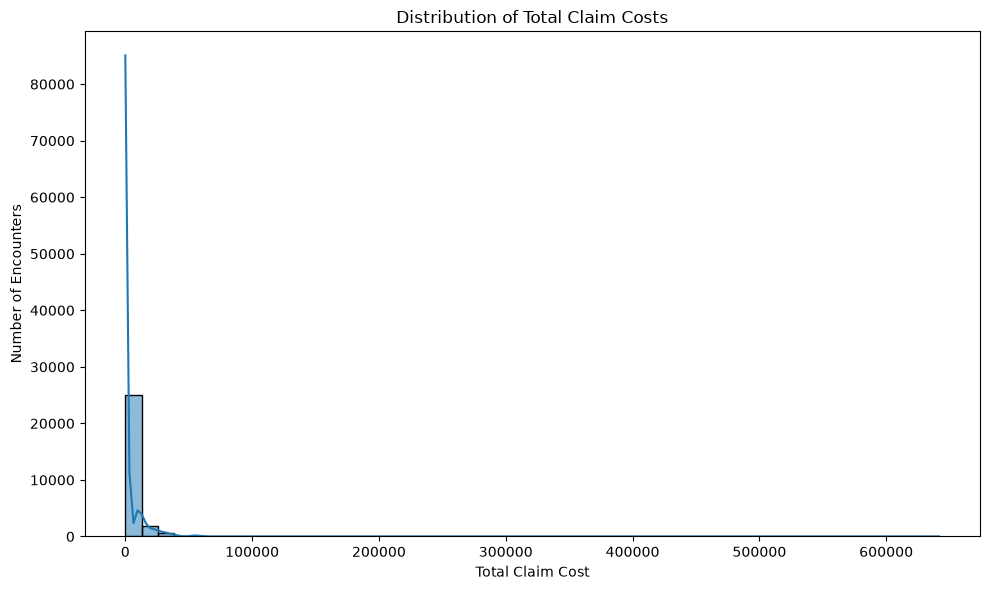

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    encounters["TOTAL_CLAIM_COST"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Claim Costs")
plt.xlabel("Total Claim Cost")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "images" / "01_data_quality_audit" / "cost_distribution.png")

plt.show()

Final audit summary

In [17]:
audit_summary = {
    "Patients": len(patients),
    "Encounters": len(encounters),
    "Procedures": len(procedures),
    "Payers": len(payers),
    "Organizations": len(organizations),
    "Duplicate rows": sum(df.duplicated().sum() for df in datasets.values()),
    "Orphan encounters": orphan_encounters,
    "Orphan procedures": orphan_procedures,
    "Invalid encounter dates": invalid_encounter_dates,
    "Invalid procedure dates": invalid_procedure_dates,
    "Negative claim costs": negative_claim_cost,
    "Negative payer coverage": negative_payer_coverage,
    "Coverage above claim cost": coverage_above_claim
}

audit_summary

{'Patients': 974,
 'Encounters': 27891,
 'Procedures': 47701,
 'Payers': 10,
 'Organizations': 1,
 'Duplicate rows': np.int64(0),
 'Orphan encounters': np.int64(0),
 'Orphan procedures': np.int64(0),
 'Invalid encounter dates': np.int64(0),
 'Invalid procedure dates': np.int64(0),
 'Negative claim costs': np.int64(0),
 'Negative payer coverage': np.int64(0),
 'Coverage above claim cost': np.int64(0)}

Conclusion

In [18]:
print("""
DATA QUALITY AUDIT CONCLUSION
=============================

The datasets were successfully loaded and inspected.

Key findings:
- No duplicate records were identified.
- Encounter-to-patient relationships are intact.
- Encounter-to-payer relationships are intact.
- Encounter-to-organization relationships are intact.
- Procedure-to-encounter relationships are intact.
- No invalid encounter dates were identified.
- No invalid procedure dates were identified.
- No negative claim costs were identified.
- No negative payer coverage values were identified.
- Missing values are concentrated in optional clinical and demographic fields.

The database is structurally suitable for the next stages of healthcare
analytics, while missing-value patterns should be documented as part of
the project's limitations and assumptions.
""")


DATA QUALITY AUDIT CONCLUSION

The datasets were successfully loaded and inspected.

Key findings:
- No duplicate records were identified.
- Encounter-to-patient relationships are intact.
- Encounter-to-payer relationships are intact.
- Encounter-to-organization relationships are intact.
- Procedure-to-encounter relationships are intact.
- No invalid encounter dates were identified.
- No invalid procedure dates were identified.
- No negative claim costs were identified.
- No negative payer coverage values were identified.
- Missing values are concentrated in optional clinical and demographic fields.

The database is structurally suitable for the next stages of healthcare
analytics, while missing-value patterns should be documented as part of
the project's limitations and assumptions.

